# Averaged error estimation

Calculate the averaged error with the RUS process and coherent error cancellation


k = 5,7,9

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

### Revised code for RUS error estimation: 1st-order error case

In [2]:
# number of rotation gates
k_List = [5,7,9]
N_k = 3

# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 80
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud1 <= c k p
c = 1/15

# Fixed small physical error rate
p = 1e-3

# Truncation 
Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))


def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)
    

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        # register for the averaged error
        PL = 0
        # register for accumulated error
        PL_K_accumu = 0

        # start the wrapping process
        K = 1
        phi_try = phi
        while K < Kmax+1:
            # wrapping process
            # if phi_try > np.pi/8:
            #     phi_try = phi_try - np.pi/4
            # elif phi_try <= -np.pi/8:
            #     phi_try = phi_try + np.pi/4
            
            if phi_try > np.pi/8:
                phi_try = abs(phi_try - np.pi/4) 
            
            # dichotomy search for exact theta
            theta_try = solve_theta_scipy(phi_try, k)
            # theta_try_abs = abs(theta_try)

            # estimating PL_MK for the coherent error mitigation channel
            # Pid_suc = (1 - c*k*p)*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pud_suc = c*k*p*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            PL_MK = Pud_suc / (Pid_suc + Pud_suc)

            # calculate the erroneous angle
            p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                        *np.cos(theta_try) )
            Delta_theta = abs(phi_try - phi_error)

            # error for the specific error mitigated channel                
            Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

            PL_K_accumu = PL_K_accumu + Error_KM

            PL = PL + ( 2**(-K) ) *PL_K_accumu

            # update variables
            K = K + 1
            phi_try = phi_try * 2

        PL_results[id_k, id_phi] = PL
        alpha = PL/( np.abs(phi)*(p) )
        alpha_results[id_k, id_phi] = alpha

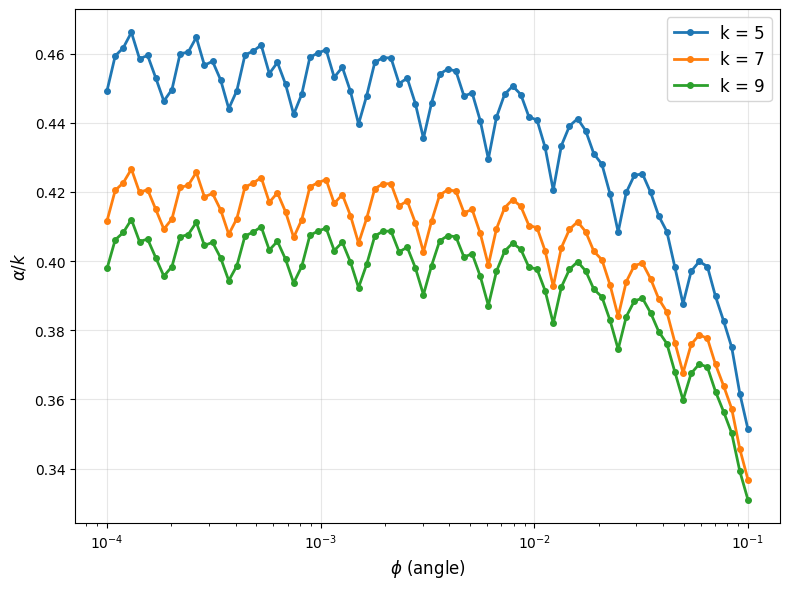

In [11]:
# Assuming you have:
# alpha_results: 2D numpy array with shape (3, N_phi)
# k_List = [5, 7, 9]
# phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot each k value as a separate line
for id_k, k in enumerate(k_List):
    plt.plot(phi_List, alpha_results[id_k, :]/k, 
             label=f'k = {k}', 
             marker='o', markersize=4, linewidth=2)

# Customize the plot
plt.xscale('log')  # Since phi_List is logspaced
plt.xlabel(r'$\phi$ (angle)', fontsize=12)
plt.ylabel(r'$\alpha/k$', fontsize=12)
# plt.title(r'Dependence of \alpha on \phi for different k values', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Optional: Improve layout
plt.tight_layout()

# Show the plot
plt.show()

### RUS error estimation: 2nd-order error case; consider the dispersive coupling

In [3]:
# number of rotation gates
k_List = [5,7,9]
N_k = 3

# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 80
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud1 <= c k p**2
c = 3

# Fixed small physical error rate
p = 1e-3

# Truncation 
Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))


def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)
    

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        # register for the averaged error
        PL = 0
        # register for accumulated error
        PL_K_accumu = 0

        # start the wrapping process
        K = 1
        phi_try = phi
        while K < Kmax+1:
            # wrapping process
            # if phi_try > np.pi/8:
            #     phi_try = phi_try - np.pi/4
            # elif phi_try <= -np.pi/8:
            #     phi_try = phi_try + np.pi/4
            
            if phi_try > np.pi/8:
                phi_try = abs(phi_try - np.pi/4) 
            
            # dichotomy search for exact theta
            theta_try = solve_theta_scipy(phi_try, k)
            # theta_try_abs = abs(theta_try)

            # estimating PL_MK for the coherent error mitigation channel
            # Pid_suc = (1 - c*k*(p**2))*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pud_suc = c*k*(p**2)*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            PL_MK = Pud_suc / (Pid_suc + Pud_suc)

            # calculate the erroneous angle
            p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                        *np.cos(theta_try) )
            Delta_theta = abs(phi_try - phi_error)

            # error for the specific error mitigated channel                
            Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

            PL_K_accumu = PL_K_accumu + Error_KM

            PL = PL + ( 2**(-K) ) *PL_K_accumu

            # update variables
            K = K + 1
            phi_try = phi_try * 2

        PL_results[id_k, id_phi] = PL
        alpha = PL/( np.abs(phi)*(p**2) )
        alpha_results[id_k, id_phi] = alpha

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


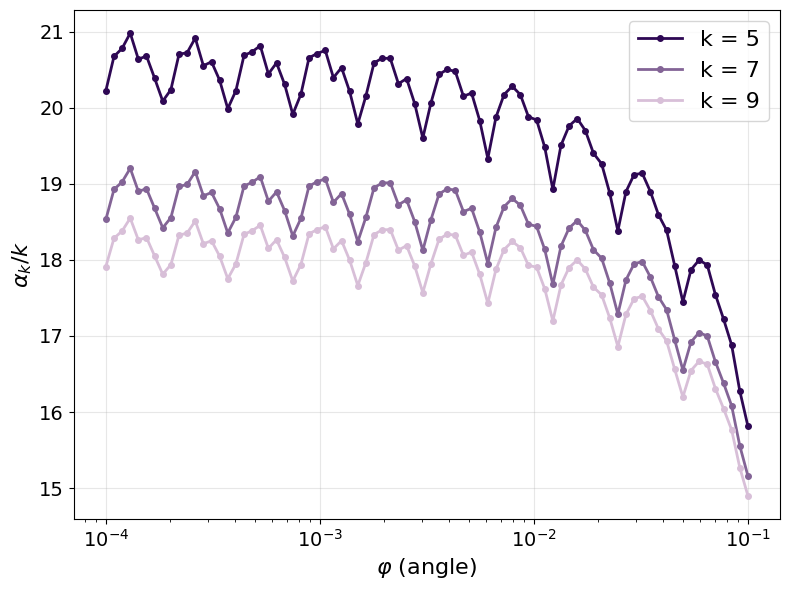

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(8, 6))

# Create a custom purple colormap from dark to light
cmap = LinearSegmentedColormap.from_list('purple_gradient', ['#2E0854', '#D8BFD8'])

# Plot each k value with colors from the gradient
for id_k, k in enumerate(k_List):
    # Normalize position in the gradient (0 for first, 1 for last)
    color_pos = id_k / (len(k_List) - 1) if len(k_List) > 1 else 0.5
    color = cmap(color_pos)
    
    plt.plot(phi_List, alpha_results[id_k, :]/k, 
             label=f'k = {k}', 
             color=color,
             marker='o', markersize=4, linewidth=2)

plt.xscale('log')
plt.xlabel(r'$\varphi$ (angle)', fontsize=16)
plt.ylabel(r'$\alpha_k/k$', fontsize=16)
plt.legend(fontsize=16)

# Increase tick label sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot as EPS file
plt.savefig('Alpha_RUS.eps', format='eps', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


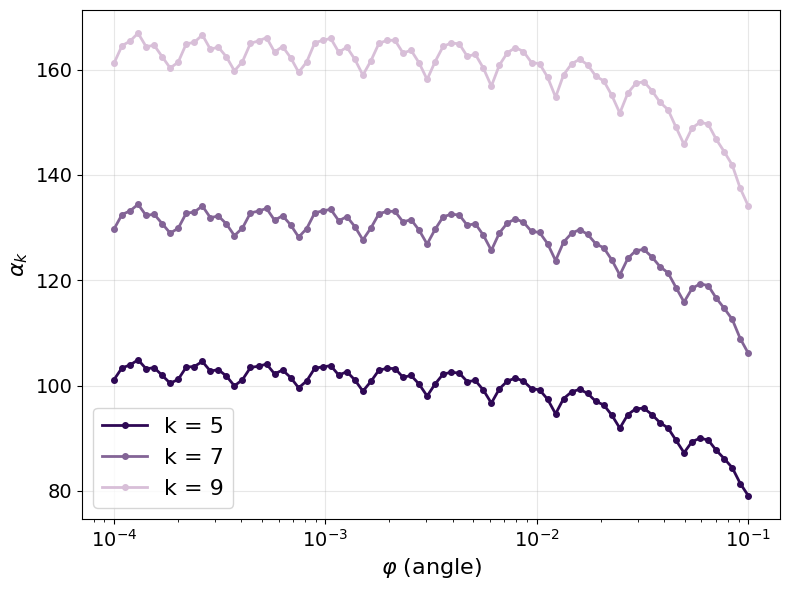

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(8, 6))

# Create a custom purple colormap from dark to light
cmap = LinearSegmentedColormap.from_list('purple_gradient', ['#2E0854', '#D8BFD8'])

# Plot each k value with colors from the gradient
for id_k, k in enumerate(k_List):
    # Normalize position in the gradient (0 for first, 1 for last)
    color_pos = id_k / (len(k_List) - 1) if len(k_List) > 1 else 0.5
    color = cmap(color_pos)
    
    plt.plot(phi_List, alpha_results[id_k, :], 
             label=f'k = {k}', 
             color=color,
             marker='o', markersize=4, linewidth=2)

plt.xscale('log')
plt.xlabel(r'$\varphi$ (angle)', fontsize=16)
plt.ylabel(r'$\alpha_k$', fontsize=16)
plt.legend(fontsize=16)

# Increase tick label sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot as EPS file
# plt.savefig('Alpha_RUS.eps', format='eps', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

#### Suppose the error does not increase with k: it is close to a given value

In [3]:
# number of rotation gates
k_List = [5,7,9]
N_k = 3

# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 80
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud1 <= c k p**2
c = 3.3
# c_fixed = 14.7  # k independent
c_fixed = 1.56

# Fixed small physical error rate
p = 1e-3

# Truncation 
Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))

PL_fixed_results = np.zeros((1,N_phi))
alpha_fixed_results = np.zeros((1,N_phi))

def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)
    

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        # register for the averaged error
        PL = 0
        # register for accumulated error
        PL_K_accumu = 0

        # start the wrapping process
        K = 1
        phi_try = phi
        while K < Kmax+1:
            # wrapping process
            # if phi_try > np.pi/8:
            #     phi_try = phi_try - np.pi/4
            # elif phi_try <= -np.pi/8:
            #     phi_try = phi_try + np.pi/4
            
            if phi_try > np.pi/8:
                phi_try = abs(phi_try - np.pi/4) 
            
            # dichotomy search for exact theta
            theta_try = solve_theta_scipy(phi_try, k)
            # theta_try_abs = abs(theta_try)

            # estimating PL_MK for the coherent error mitigation channel
            # Pid_suc = (1 - c*k*(p**2))*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pud_suc = c*k*(p**2)*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            PL_MK = Pud_suc / (Pid_suc + Pud_suc)

            # calculate the erroneous angle
            p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                        *np.cos(theta_try) )
            Delta_theta = abs(phi_try - phi_error)

            # error for the specific error mitigated channel                
            Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

            PL_K_accumu = PL_K_accumu + Error_KM

            PL = PL + ( 2**(-K) ) *PL_K_accumu

            # update variables
            K = K + 1
            phi_try = phi_try * 2

        PL_results[id_k, id_phi] = PL
        alpha = PL/( np.abs(phi)*(p**2) )
        alpha_results[id_k, id_phi] = alpha


# fix the error: fix it to be 12*phi*(p**2) 

for id_phi, phi in enumerate(phi_List):
    # register for the averaged error
    PL = 0
    # register for accumulated error
    PL_K_accumu = 0

    # start the wrapping process
    K = 1
    phi_try = phi
    while K < Kmax+1:
        # wrapping process
        # if phi_try > np.pi/8:
        #     phi_try = phi_try - np.pi/4
        # elif phi_try <= -np.pi/8:
        #     phi_try = phi_try + np.pi/4
        
        if phi_try > np.pi/8:
            phi_try = abs(phi_try - np.pi/4) 
        
        # dichotomy search for exact theta
        theta_try = solve_theta_scipy(phi_try, k)
        # theta_try_abs = abs(theta_try)

        # estimating PL_MK for the coherent error mitigation channel
        # Pid_suc = (1 - c*k*(p**2))*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
        Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
        Pud_suc = c_fixed*(p**2)*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
        PL_MK = Pud_suc / (Pid_suc + Pud_suc)

        # calculate the erroneous angle
        p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
        phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                    *np.cos(theta_try) )
        Delta_theta = abs(phi_try - phi_error)

        # error for the specific error mitigated channel                
        Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

        PL_K_accumu = PL_K_accumu + Error_KM

        PL = PL + ( 2**(-K) ) *PL_K_accumu

        # update variables
        K = K + 1
        phi_try = phi_try * 2

    PL_fixed_results[0, id_phi] = PL
    alpha = PL/( np.abs(phi)*(p**2) )
    alpha_fixed_results[0, id_phi] = alpha

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


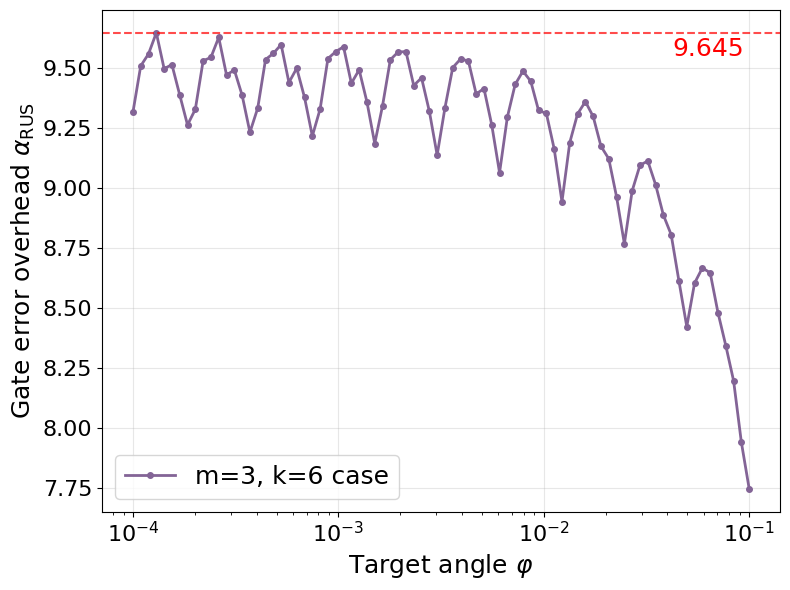

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(8, 6))

# Create a custom purple colormap from dark to light
cmap = LinearSegmentedColormap.from_list('purple_gradient', ['#2E0854', '#D8BFD8'])

# # Plot each k value with colors from the gradient
# for id_k, k in enumerate(k_List):
#     # Normalize position in the gradient (0 for first, 1 for last)
#     color_pos = id_k / (len(k_List) - 1) if len(k_List) > 1 else 0.5
#     color = cmap(color_pos)
    
#     plt.plot(phi_List, alpha_results[id_k, :]/k, 
#             label=f'k = {k}', 
#             color=color,
#             marker='o', markersize=4, linewidth=2)


# Plot fixed P_ud2 case
color_pos = 0.5
color = cmap(color_pos)

# Calculate the maximum y-value for the horizontal line
max_y_value = np.max(alpha_fixed_results[0, :])

plt.plot(phi_List, alpha_fixed_results[0, :], 
        label='m=3, k=6 case', 
        color=color,
        marker='o', markersize=4, linewidth=2)

# Add horizontal dashed line at maximum value
plt.axhline(y=max_y_value, color='red', linestyle='--', linewidth=1.5, 
           alpha=0.7)

# Add text label above the horizontal line
plt.text(plt.xlim()[1] * 0.9, max_y_value *0.988,  # Position at right side, slightly above line
         f'{max_y_value:.3f}', 
         fontsize=18, 
         color='red',
         ha='right', va='bottom')

plt.xscale('log')
plt.xlabel(r"Target angle $\varphi$", fontsize=18)
plt.ylabel(r"Gate error overhead $\alpha_{\mathrm{RUS}}$", fontsize=18)
plt.legend(fontsize=18)

# Increase tick label sizes
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot as EPS file
plt.savefig('Alpha_RUS.eps', format='eps', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

#### main: Consider the magic-state-cultivation T for the wrapping

In [54]:
# number of rotation gates
k_List = [5,7,9]
N_k = 3

# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 80
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud1 <= c k p**2
c = 3.3
c_fixed = 14.7  # k independent

# Fixed small physical error rate
p = 1e-3

# Truncation 
Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))

PL_fixed_results = np.zeros((1,N_phi))
alpha_fixed_results = np.zeros((1,N_phi))

def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)
    

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        # register for the averaged error
        PL = 0
        # register for accumulated error
        PL_K_accumu = 0

        # start the wrapping process
        K = 1
        phi_try = phi
        while K < Kmax+1:
            # wrapping process
            # if phi_try > np.pi/8:
            #     phi_try = phi_try - np.pi/4
            # elif phi_try <= -np.pi/8:
            #     phi_try = phi_try + np.pi/4
            
            if phi_try > np.pi/16:
                phi_try = abs(phi_try - np.pi/8) 
                PL_K_accumu = PL_K_accumu + 2e-9
            
            # dichotomy search for exact theta
            theta_try = solve_theta_scipy(phi_try, k)
            # theta_try_abs = abs(theta_try)

            # estimating PL_MK for the coherent error mitigation channel
            # Pid_suc = (1 - c*k*(p**2))*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pud_suc = c*k*(p**2)*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            PL_MK = Pud_suc / (Pid_suc + Pud_suc)

            # calculate the erroneous angle
            p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                        *np.cos(theta_try) )
            Delta_theta = abs(phi_try - phi_error)

            # error for the specific error mitigated channel                
            Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

            PL_K_accumu = PL_K_accumu + Error_KM

            PL = PL + ( 2**(-K) ) *PL_K_accumu

            # update variables
            K = K + 1
            phi_try = phi_try * 2

        PL_results[id_k, id_phi] = PL
        alpha = PL/( np.abs(phi)*(p**2) )
        alpha_results[id_k, id_phi] = alpha


# fix the error: fix it to be 12*phi*(p**2) 

for id_phi, phi in enumerate(phi_List):
    # register for the averaged error
    PL = 0
    # register for accumulated error
    PL_K_accumu = 0

    # start the wrapping process
    K = 1
    phi_try = phi
    while K < Kmax+1:
        # wrapping process
        # if phi_try > np.pi/8:
        #     phi_try = phi_try - np.pi/4
        # elif phi_try <= -np.pi/8:
        #     phi_try = phi_try + np.pi/4
        
        if phi_try > np.pi/16:
            phi_try = abs(phi_try - np.pi/8) 
            PL_K_accumu = PL_K_accumu + 2e-9

        # dichotomy search for exact theta
        theta_try = solve_theta_scipy(phi_try, k)
        # theta_try_abs = abs(theta_try)

        # estimating PL_MK for the coherent error mitigation channel
        # Pid_suc = (1 - c*k*(p**2))*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
        Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
        Pud_suc = c_fixed*(p**2)*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
        PL_MK = Pud_suc / (Pid_suc + Pud_suc)

        # calculate the erroneous angle
        p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
        phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                    *np.cos(theta_try) )
        Delta_theta = abs(phi_try - phi_error)

        # error for the specific error mitigated channel                
        Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

        PL_K_accumu = PL_K_accumu + Error_KM

        PL = PL + ( 2**(-K) ) *PL_K_accumu

        # update variables
        K = K + 1
        phi_try = phi_try * 2

    PL_fixed_results[0, id_phi] = PL
    alpha = PL/( np.abs(phi)*(p**2) )
    alpha_fixed_results[0, id_phi] = alpha

C:\Users\zengp\AppData\Local\Temp\ipykernel_16324\2170840642.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


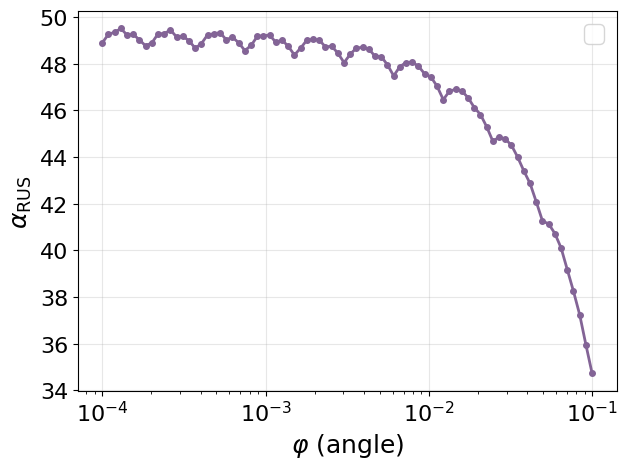

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# plt.figure(figsize=(8, 6))

# Create a custom purple colormap from dark to light
cmap = LinearSegmentedColormap.from_list('purple_gradient', ['#2E0854', '#D8BFD8'])

# # Plot each k value with colors from the gradient
# for id_k, k in enumerate(k_List):
#     # Normalize position in the gradient (0 for first, 1 for last)
#     color_pos = id_k / (len(k_List) - 1) if len(k_List) > 1 else 0.5
#     color = cmap(color_pos)
    
#     plt.plot(phi_List, alpha_results[id_k, :]/k, 
#             label=f'k = {k}', 
#             color=color,
#             marker='o', markersize=4, linewidth=2)


# Plot fixed P_ud2 case
color_pos = 0.5
color = cmap(color_pos)

plt.plot(phi_List, alpha_fixed_results[0, :], 
        # label='asymptotic', 
        color = color,
        marker='o', markersize=4, linewidth=2)


plt.xscale('log')
plt.xlabel(r'$\varphi$ (angle)', fontsize=18)
plt.ylabel(r'$\alpha_{\mathrm{RUS}}$', fontsize=18)
plt.legend(fontsize=18)

# Increase tick label sizes
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot as EPS file
plt.savefig('Alpha_RUS_Twrap.eps', format='eps', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

### Protocol switching

In [4]:
# number of rotation gates
k_List = [5,7,9]
N_k = 3

# target rotation angle
phi_min = 1e-4
phi_max = np.pi/8
N_phi = 80
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud1 <= c k p**2
c = 3.3

# Fixed small physical error rate
p = 1e-3

# Truncation 
Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))


def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)
    

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        # register for the averaged error
        PL = 0
        # register for accumulated error
        PL_K_accumu = 0

        # start the wrapping process
        K = 1
        phi_try = phi
        while K < Kmax+1:
            # wrapping process
            # if phi_try > np.pi/8:
            #     phi_try = phi_try - np.pi/4
            # elif phi_try <= -np.pi/8:
            #     phi_try = phi_try + np.pi/4
            
            if phi_try > np.pi/8:
                phi_try = abs(phi_try - np.pi/4) 
            
            # dichotomy search for exact theta
            theta_try = solve_theta_scipy(phi_try, k)
            # theta_try_abs = abs(theta_try)

            # estimating PL_MK for the coherent error mitigation channel
            # Pid_suc = (1 - c*k*(p**2))*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pud_suc = c*k*(p**2)*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            PL_MK = Pud_suc / (Pid_suc + Pud_suc)

            # calculate the erroneous angle
            p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                        *np.cos(theta_try) )
            Delta_theta = abs(phi_try - phi_error)

            # error for the specific error mitigated channel                
            Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

            PL_K_accumu = PL_K_accumu + Error_KM

            PL = PL + ( 2**(-K) ) *PL_K_accumu

            # update variables
            K = K + 1
            phi_try = phi_try * 2

        PL_results[id_k, id_phi] = PL
        alpha = PL/( np.abs(phi)*(p**2) )
        alpha_results[id_k, id_phi] = alpha

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


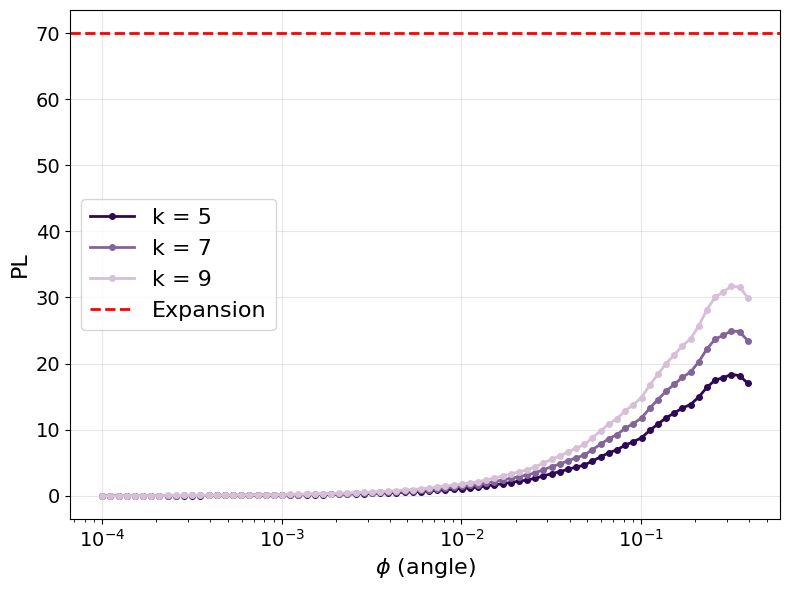

In [5]:
# Compare the projection scheme and the expansion scheme

# assume we have PL_results[id_k, id_phi]

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(8, 6))

# Create the same custom purple colormap from dark to light
cmap = LinearSegmentedColormap.from_list('purple_gradient', ['#2E0854', '#D8BFD8'])

# Plot each k value with colors from the gradient (consistent with alpha plot)
for id_k, k in enumerate(k_List):
    # Normalize position in the gradient (0 for first, 1 for last)
    color_pos = id_k / (len(k_List) - 1) if len(k_List) > 1 else 0.5
    color = cmap(color_pos)
    
    plt.plot(phi_List, PL_results[id_k, :]/(p**2), 
             label=f'k = {k}', 
             color=color,
             marker='o', markersize=4, linewidth=2)

# Add horizontal dashed line at 70
plt.axhline(y=70, color='red', linestyle='--', linewidth=2, label='Expansion')

plt.xscale('log')  # Since phi_List is logspaced
plt.xlabel(r'$\phi$ (angle)', fontsize=16)
plt.ylabel('PL', fontsize=16)
plt.legend(fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot as EPS file
plt.savefig('PL_RUS.eps', format='eps', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


### test the dichotomy function

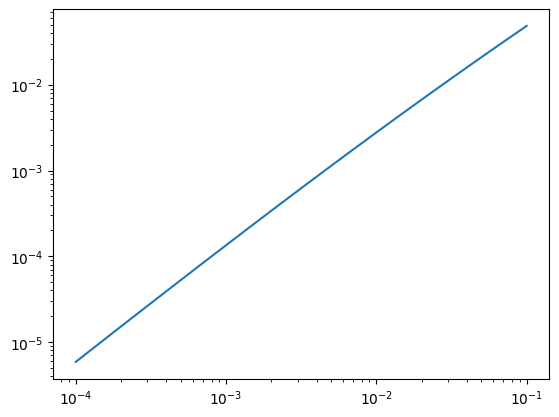

In [ ]:
# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 60
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

theta_list = np.zeros(N_phi)
Delta_list = np.zeros(N_phi)

k = 5


def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    
    Parameters:
    - phi: float, between 0 and pi/10
    - k: float, exponent in the equation
    - delta: float, desired accuracy (default 1e-7)
    
    Returns:
    - theta: float, solution in radians between 0 and pi/4
    """
    a = -np.pi / 4
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        numerator = sin_theta ** k
        p_ideal = (sin_theta ** (2 * k)) + (cos_theta ** (2 * k))
        return (numerator / p_ideal) - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        raise ValueError("Function may not have a root in [-pi/4, pi/4]")
    
    while (b - a) >= delta:
        c = (a + b) / 2
        fc = f(c)
        
        if fc == 0.0:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
    
    return (a + b) / 2



for id_phi, phi in enumerate(phi_List):
    theta_try = solve_theta(phi, k)
    # theta_try =  phi**(1/k)
    
    p_ideal = np.sin(theta_try)**(2*k) + np.cos(theta_try)**(2*k)
    phi_try = np.arcsin( (np.sin(theta_try)**k)/np.sqrt( p_ideal ) )

    Delta_list[id_phi] = abs(phi_try - phi)

plt.loglog(phi_List, Delta_list)

phi=1.00e-04, theta=3.450078e-01, Delta=2.71e-20
phi=1.12e-04, theta=3.491690e-01, Delta=1.68e-16
phi=1.26e-04, theta=3.533719e-01, Delta=1.20e-16
phi=1.42e-04, theta=3.576166e-01, Delta=5.29e-18
phi=1.60e-04, theta=3.619031e-01, Delta=2.98e-19


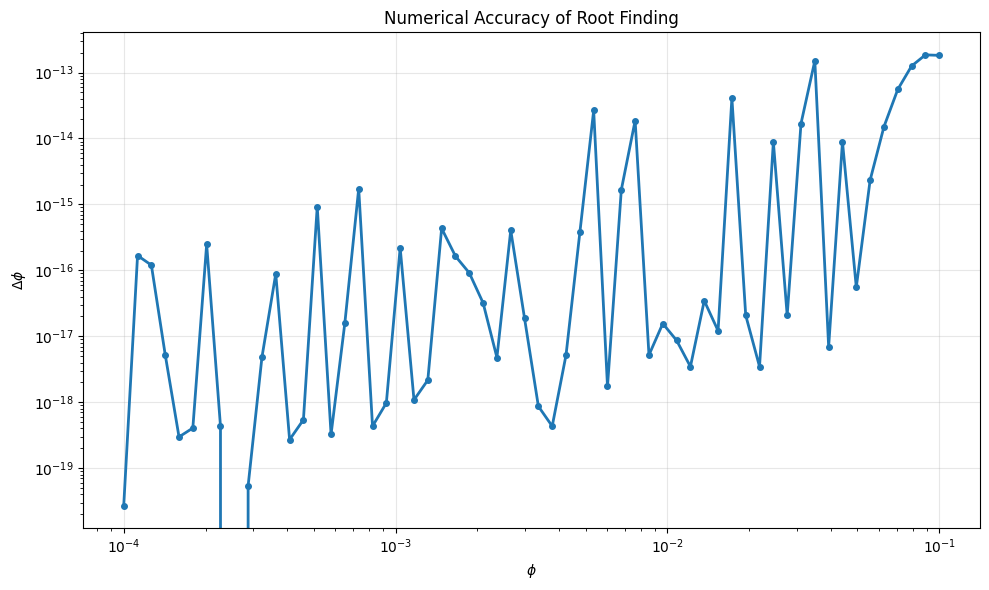

Max error: 1.85e-13
Mean error: 1.41e-14


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
phi_min = 1e-4
phi_max = 1e-1
N_phi = 60
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

theta_list = np.zeros(N_phi)
Delta_list = np.zeros(N_phi)
k = 9

def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)

# Test both methods
for id_phi, phi in enumerate(phi_List):
    # Use the improved method
    theta_try = solve_theta_scipy(phi, k)
    theta_list[id_phi] = theta_try
    
    # Calculate phi_try with improved numerical stability
    sin_theta = np.sin(theta_try)
    cos_theta = np.cos(theta_try)
    
    # Use logarithmic form
    log_sin = k * np.log(sin_theta)
    log_cos = k * np.log(cos_theta)
    
    numerator = np.exp(log_sin)
    denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
    phi_try = np.arcsin(numerator / denominator)
    
    Delta_list[id_phi] = abs(phi_try - phi)
    
    # Debug output for first few points
    if id_phi < 5:
        print(f"phi={phi:.2e}, theta={theta_try:.6e}, Delta={Delta_list[id_phi]:.2e}")

# Plot results
plt.figure(figsize=(10, 6))
plt.loglog(phi_List, Delta_list, 'o-', linewidth=2, markersize=4)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\Delta\phi$')
plt.title('Numerical Accuracy of Root Finding')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if results are reasonable
print(f"Max error: {np.max(Delta_list):.2e}")
print(f"Mean error: {np.mean(Delta_list):.2e}")

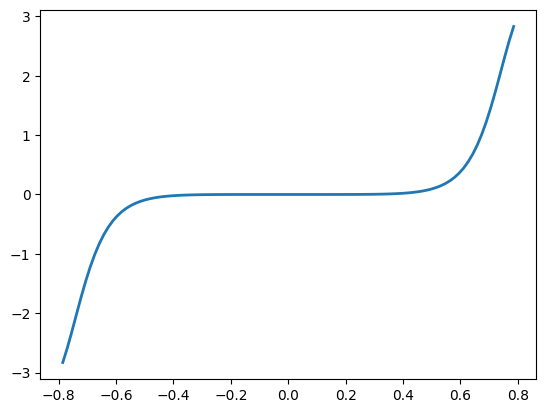

In [26]:
k = 5
def f(theta, k):
        return ( (np.sin(theta)) ** k )/( (np.sin(theta) **(2*k)) + (np.cos(theta) **(2*k)) )

theta_List = np.linspace(-np.pi/4, np.pi/4, 100)

plt.plot(theta_List, f(theta_List,k), 
        markersize=6,
        linewidth=2)


In [36]:
k_List = [5,7,9]
N_k = 3

phi_min = 1e-4
phi_max = 1e-1
N_phi = 30
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud2 upper bound overhead: Pud2 <= c k p^2
c = 3

# Physical error rate: p = 1e-3
p = 1e-3

Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))

import numpy as np

def solve_theta(phi, k, delta=1e-8):
    """
    Solve for theta using the dichotomy method given phi and k.
    
    Parameters:
    - phi: float, between 0 and pi/10
    - k: float, exponent in the equation
    - delta: float, desired accuracy (default 1e-7)
    
    Returns:
    - theta: float, solution in radians between 0 and pi/4
    """
    a = -np.pi / 4
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        numerator = sin_theta ** k
        denominator = (sin_theta ** (2 * k)) + (cos_theta ** (2 * k))
        return numerator / denominator - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        raise ValueError("Function may not have a root in [-pi/4, pi/4]")
    
    while (b - a) >= delta:
        c = (a + b) / 2
        fc = f(c)
        
        if fc == 0.0:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
    
    return (a + b) / 2

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        PL = 0
        for K in range(1,41):   # RUS trial number K

            PL_K = 0
            for M in range(1,K+1):     # Until K, we do coherent error mitigation for each M
                phi_try = (2**(M-1)) * phi
                # wrapping phi_try
                period = np.pi / 4
                phi_try_wrapped = ((phi_try + period/2) % period) - period/2

                theta_try = solve_theta(phi_try_wrapped, k)
                Pud2_U = c*k*(p**2)

                Error_KM = 2 * Pud2_U * ( theta_try**(2*k-2) )

                PL_K = PL_K + Error_KM
            
            PL = PL + ( 2**(-K) ) * PL_K

        PL_results[id_k, id_phi] = PL
        alpha = PL/(np.abs(phi)*(p**2))
        alpha_results[id_k, id_phi] = alpha



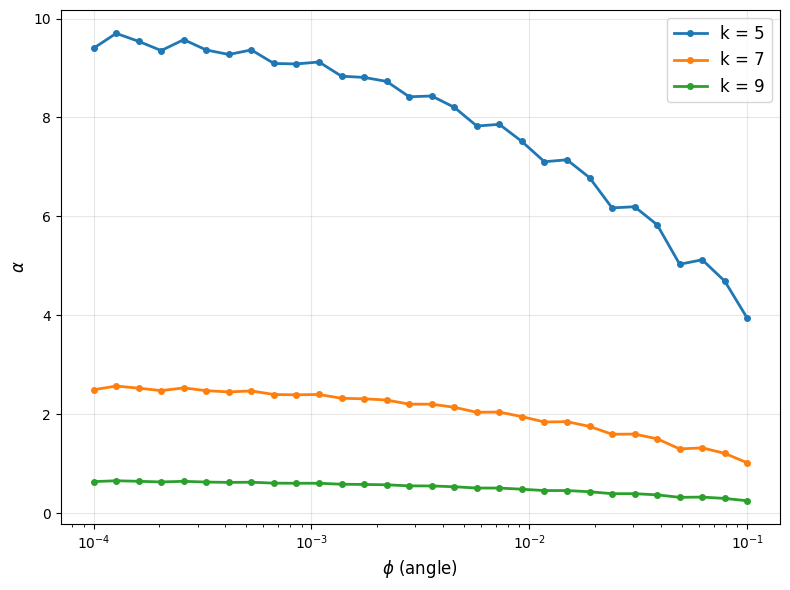

In [37]:
# Assuming you have:
# alpha_results: 2D numpy array with shape (3, N_phi)
# k_List = [5, 7, 9]
# phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot each k value as a separate line
for id_k, k in enumerate(k_List):
    plt.plot(phi_List, alpha_results[id_k, :], 
             label=f'k = {k}', 
             marker='o', markersize=4, linewidth=2)

# Customize the plot
plt.xscale('log')  # Since phi_List is logspaced
plt.xlabel(r'$\phi$ (angle)', fontsize=12)
plt.ylabel(r'$\alpha$', fontsize=12)
# plt.title(r'Dependence of \alpha on \phi for different k values', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Optional: Improve layout
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
k_List = [5,7,9]
N_k = 3

phi_min = 1e-4
phi_max = 1e-1
N_phi = 30
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud2 <= c k p
c = 1/15

# Physical error rate: p = 1e-3
p = 1e-3

Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))


def solve_theta(phi, k, delta=1e-8):
    """
    Solve for theta using the dichotomy method given phi and k.
    
    Parameters:
    - phi: float, between 0 and pi/10
    - k: float, exponent in the equation
    - delta: float, desired accuracy (default 1e-7)
    
    Returns:
    - theta: float, solution in radians between 0 and pi/4
    """
    a = -np.pi / 4
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        numerator = sin_theta ** k
        denominator = (sin_theta ** (2 * k)) + (cos_theta ** (2 * k))
        return numerator / denominator - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        raise ValueError("Function may not have a root in [-pi/4, pi/4]")
    
    while (b - a) >= delta:
        c = (a + b) / 2
        fc = f(c)
        
        if fc == 0.0:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
    
    return (a + b) / 2

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        PL = 0
        for K in range(1,Kmax+1):   # RUS trial number K

            PL_K = 0
            for M in range(1,K+1):     # Until K, we do coherent error mitigation for each M
                phi_try = (2**(M-1)) * phi
                # wrapping phi_try
                period = np.pi / 4
                phi_try_wrapped = ((phi_try + period/2) % period) - period/2

                # dichotomy search for exact theta
                # theta_try = solve_theta(phi_try_wrapped, k)

                # approximate calculation of theta
                if phi_try_wrapped > 0:
                    theta_try =  phi_try_wrapped**(1/k)
                else:
                    theta_try = - abs(phi_try_wrapped)**(1/k)
                if np.isnan(theta_try):
                    print(f"Error: theta is NaN when phi = {phi_try_wrapped}")
                    raise ValueError(f"theta is NaN when phi = {phi_try_wrapped}")

                Pud2_U = c*k*p

                # Error_KM = 2 * Pud2_U * ( theta_try**(2*k-2) )
                Error_KM = 2 * Pud2_U * ( theta_try**(2*k-2) )

                PL_K = PL_K + Error_KM
            
            PL = PL + ( 2**(-K) ) * PL_K

        PL_results[id_k, id_phi] = PL
        alpha = PL/(np.abs(phi)*(p))
        alpha_results[id_k, id_phi] = alpha

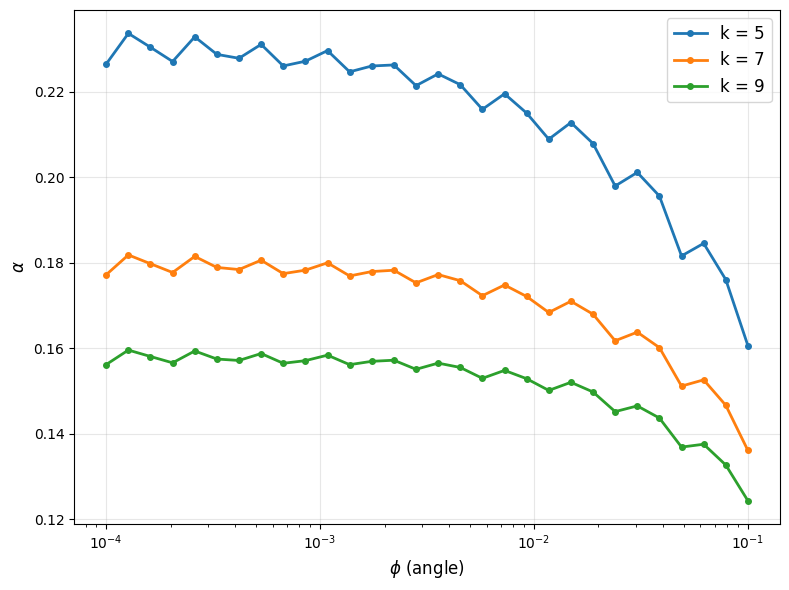

In [52]:
# Assuming you have:
# alpha_results: 2D numpy array with shape (3, N_phi)
# k_List = [5, 7, 9]
# phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot each k value as a separate line
for id_k, k in enumerate(k_List):
    plt.plot(phi_List, alpha_results[id_k, :]/k, 
             label=f'k = {k}', 
             marker='o', markersize=4, linewidth=2)

# Customize the plot
plt.xscale('log')  # Since phi_List is logspaced
plt.xlabel(r'$\phi$ (angle)', fontsize=12)
plt.ylabel(r'$\alpha$', fontsize=12)
# plt.title(r'Dependence of \alpha on \phi for different k values', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Optional: Improve layout
plt.tight_layout()

# Show the plot
plt.show()

### Spacetime cost estimation of the RUS process

In [ ]:
# import phi_list and SuccProb_list

with open('MainProjFailprobVSAngle251113.pkl', 'rb') as file:
    data = pickle.load(file)

phi_list = data['phi_list']
Result_m3_18_List = data['Result_m3_18_List']
SuccProb_list = 1 - Result_m3_18_List[:,1]

SuccProb_list

array([0.07260467, 0.07075133, 0.06922333, 0.066876  , 0.06470867,
       0.06285467, 0.06033867, 0.05821267, 0.05580267, 0.05311133,
       0.050364  , 0.04797867, 0.045308  , 0.04223333, 0.03952333,
       0.036922  , 0.033644  , 0.03095733, 0.02815067, 0.02556267,
       0.02288933, 0.020728  , 0.01818133, 0.01593267, 0.01399333,
       0.01218067, 0.01021467, 0.00880133, 0.00735733, 0.00616933])

In [21]:
def predict_succprob(phi, phi_list, SuccProb_list):
    """
    Predict SuccProb for a given phi using piecewise linear interpolation
    between the two closest points in the log-log plot.
    
    Parameters:
    phi: float - input phi value
    phi_list: array-like - list of phi values
    SuccProb_list: array-like - list of corresponding SuccProb values
    
    Returns:
    float - predicted SuccProb value
    """
    # Convert to numpy arrays for easier manipulation
    phi_arr = np.array(phi_list).flatten()
    succ_arr = np.array(SuccProb_list).flatten()
    
    # Find the index where phi would be inserted to maintain sorted order
    idx = np.searchsorted(phi_arr, phi)
    
    # Handle edge cases
    if idx == 0:
        # phi is smaller than all values, use first two points
        left_idx, right_idx = 0, 1
    elif idx == len(phi_arr):
        # phi is larger than all values, use last two points
        left_idx, right_idx = len(phi_arr)-2, len(phi_arr)-1
    else:
        # phi is between existing points, use surrounding points
        left_idx, right_idx = idx-1, idx
    
    # Get the left and right points
    phi_left, succ_left = phi_arr[left_idx], succ_arr[left_idx]
    phi_right, succ_right = phi_arr[right_idx], succ_arr[right_idx]
    
    # Perform linear interpolation in log-log space
    log_phi = np.log(phi)
    log_phi_left = np.log(phi_left)
    log_phi_right = np.log(phi_right)
    log_succ_left = np.log(succ_left)
    log_succ_right = np.log(succ_right)
    
    # Linear interpolation in log space
    log_succ_pred = log_succ_left + (log_phi - log_phi_left) * \
                   (log_succ_right - log_succ_left) / (log_phi_right - log_phi_left)
    
    # Convert back to linear space
    succ_pred = np.exp(log_succ_pred)
    
    return succ_pred


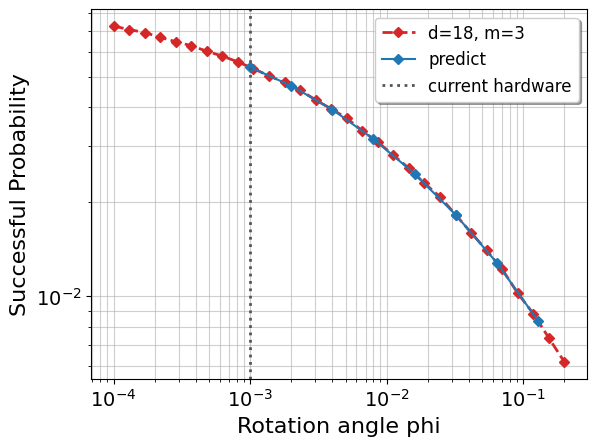

In [29]:
# Define colors and line styles
colors = {
    'm2': '#1f77b4',  # Blue for m=2
    'm3': '#d62728',   # Red for m=3
    'hw': '#555555'   # Gray for hardware line  
}

line_styles = {
    'd12': '-',       # Solid line for d=12
    'd18': '--'       # Dashed line for d=18
}

plt.plot(phi_list, SuccProb_list, 
            color=colors['m3'], linestyle=line_styles['d18'], 
            linewidth=2, marker='D', markersize=5, label='d=18, m=3')

trial_angle = [1e-3,2e-3,4e-3,8e-3,16e-3,32e-3,64e-3,128e-3]
plt.plot(trial_angle, [predict_succprob(angle, phi_list, SuccProb_list) for angle in trial_angle], 
            color=colors['m2'], marker='D', markersize=5, label='predict')

plt.xscale('log')
plt.yscale('log')

plt.axvline(x=1e-3, color=colors['hw'], linestyle=':', label='current hardware', linewidth=2)

# Customize the plot with larger fonts
plt.xlabel('Rotation angle phi', fontsize=16)  # Increased from 12 to 16
plt.ylabel('Successful Probability', fontsize=16)  # Increased from 12 to 16

# Increase tick label size
plt.xticks(fontsize=14)  # Larger x-axis tick labels
plt.yticks(fontsize=14)  # Larger y-axis tick labels

# Larger legend
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)  # Increased from 10 to 12

plt.grid(True, which="both", ls="-", alpha=0.6)


#### Main: spacetime cost estimation of the RUS procedure

In [33]:
phi = 1e-3
Kmax  = 50
QT = 6e4        # spacetime cost of magic state cultivation

def calculate_Q(p):   # spacetime cost of a single rotation state preparation (without RUS)
    """
    Calculate Q = 4536 + 1296/p
    
    Parameters:
    p: the successful probability;  float - input value (cannot be zero)
    
    Returns:
    float - calculated Q value
    """
    if p == 0:
        raise ValueError("p cannot be zero (division by zero)")
    
    Q = 4536 + 1296 / p
    return Q

# start the wrapping process
Qaccu = 0    # Register for the accumulated spacetime cost (when unsuccessful)
Qtot = 0   # Register for the expected total spacetime cost

K = 1
phi_try = phi
while K < Kmax+1:
    if abs(phi_try) > np.pi/16:
        phi_try = abs(phi_try - np.pi/8)
        Qaccu = Qaccu + QT   # T gate spacetime cost
    Qaccu = Qaccu + calculate_Q(predict_succprob(phi_try, phi_list, SuccProb_list))
    Qtot = Qtot + (1/(2**K))*Qaccu

    phi_try = phi_try*2
    K = K + 1

Qtot

np.float64(70415.02457540529)

In [32]:
calculate_Q(predict_succprob(8e-3, phi_list, SuccProb_list))

np.float64(45432.06924430867)

In [39]:
Nspin = 50
Tmax = 50
Tmin = 10
NT = 40
T_list = np.linspace(Tmin, Tmax, num=NT)

T_list.shape

(40,)

#### Main: comparison of the resource cost for the Heisenberg Hamiltonian simulation 

In [41]:
Nspin = 50
Tmax = 50
Tmin = 10
NT = 40
T_list = np.linspace(Tmin, Tmax, num=NT)

eps_c = 1e-11  # compiling accuracy requirement
cTgate = 1.149*np.log2(1/eps_c) + 9.2

# register for the spacetime cost
Q_distillation_list = np.zeros(NT)
Q_cultivation_list = np.zeros(NT)
Q_angle_list = np.zeros(NT)

Q_distillation_1 = 1840000
Q_cultivation_1 = 60000
Q_angle_1 = 70415

for idt, t in enumerate(T_list):
    # 4th-order Trotter, number of segment estimation
    # Based on the commutator bound results in the Childs et al., 2019 PRX paper
    nu = (np.exp(1.85)) * (Nspin**(0.27)) * (t**(1.25))

    Nphi = 22*Nspin*nu
    NTgate = Nphi* cTgate

    Q_distillation_list[idt] = NTgate*Q_distillation_1
    Q_cultivation_list[idt] = NTgate*Q_cultivation_1
    Q_angle_list[idt] = Nphi*Q_angle_1



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


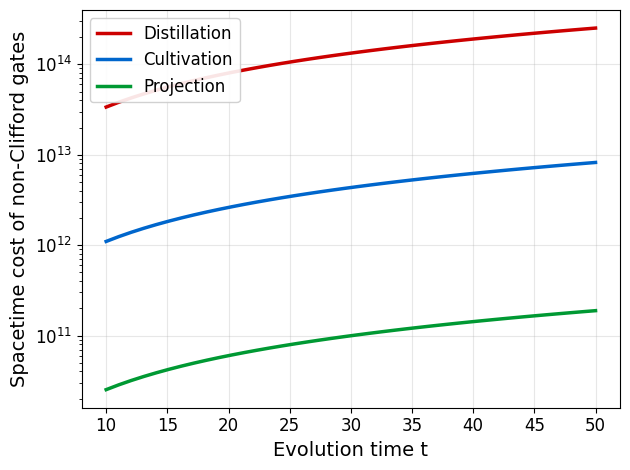

In [53]:
# Create the plot with a better style
# plt.figure(figsize=(10, 6))

# Option 1: Professional blue-orange-purple theme
# plt.plot(T_list, Q_distillation_list, color='#1f77b4', linewidth=2.5, label='Distillation')  # Blue
# plt.plot(T_list, Q_cultivation_list, color='#ff7f0e', linewidth=2.5, label='Cultivation')    # Orange
# plt.plot(T_list, Q_angle_list, color='#9467bd', linewidth=2.5, label='Projection')               # Purple

# Option 2: Alternative - Scientific publication theme (uncomment to use)
# plt.plot(T_list, Q_distillation_list, color='#2E86AB', linewidth=2.5, label='Distillation')
# plt.plot(T_list, Q_cultivation_list, color='#A23B72', linewidth=2.5, label='Cultivation') 
# plt.plot(T_list, Q_angle_list, color='#F18F01', linewidth=2.5, label='Projection')

# Option 3: High contrast theme (good for printing)
plt.plot(T_list, Q_distillation_list, color='#CC0000', linewidth=2.5, label='Distillation')
plt.plot(T_list, Q_cultivation_list, color='#0066CC', linewidth=2.5, label='Cultivation')
plt.plot(T_list, Q_angle_list, color='#009933', linewidth=2.5, label='Projection')

plt.yscale('log')

# Add labels and title
plt.xlabel('Evolution time t', fontsize=14)
plt.ylabel('Spacetime cost of non-Clifford gates', fontsize=14)
# plt.title('Spacetime Cost Comparison', fontsize=16)  # Optional title

# Add legend
plt.legend(fontsize=12, framealpha=0.9,loc='upper left')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Improve tick parameters
plt.tick_params(axis='both', which='major', labelsize=12)

# Set nice layout
plt.tight_layout()

# Save as EPS file with high quality
plt.savefig('ResourceComp.eps', format='eps', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# print("Plot saved as 'ResourceComp.eps'")